**Import libraries**

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import DecisionBoundaryDisplay
import gradio as gr

In [195]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Read_Data**

In [196]:
df=pd.read_csv("/content/drive/MyDrive/CarPrice.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


**EDA**

In [197]:
df.shape

(205, 26)

In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [199]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [200]:
df.duplicated().sum()

np.int64(0)

In [201]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


**Cleaning & Data Preparation**

In [202]:
df['brand'] = df['CarName'].str.split().str[0]
df['brand'].value_counts()

,count
brand,
toyota,31
nissan,17
mazda,15
honda,13
mitsubishi,13
subaru,12
volvo,11
peugeot,11
dodge,9


In [203]:
df['brand'] = df['brand'].replace({
    'toyouta': 'toyota',
    'vw': 'volkswagen',
    'vokswagen': 'volkswagen',
    'maxda': 'mazda',
    'porcshce': 'porsche'
})

In [204]:
df = df.drop('CarName', axis=1)

In [205]:
df.head()

,car_ID,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,1,3,gas,std,two,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,2,3,gas,std,two,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,3,1,gas,std,two,hatchback,rwd,front,94.5,171.2,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,4,2,gas,std,four,sedan,fwd,front,99.8,176.6,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,gas,std,four,sedan,4wd,front,99.4,176.6,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [206]:
numerical_cols = df.select_dtypes(include=np.number).columns

print(numerical_cols)

Index(['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')


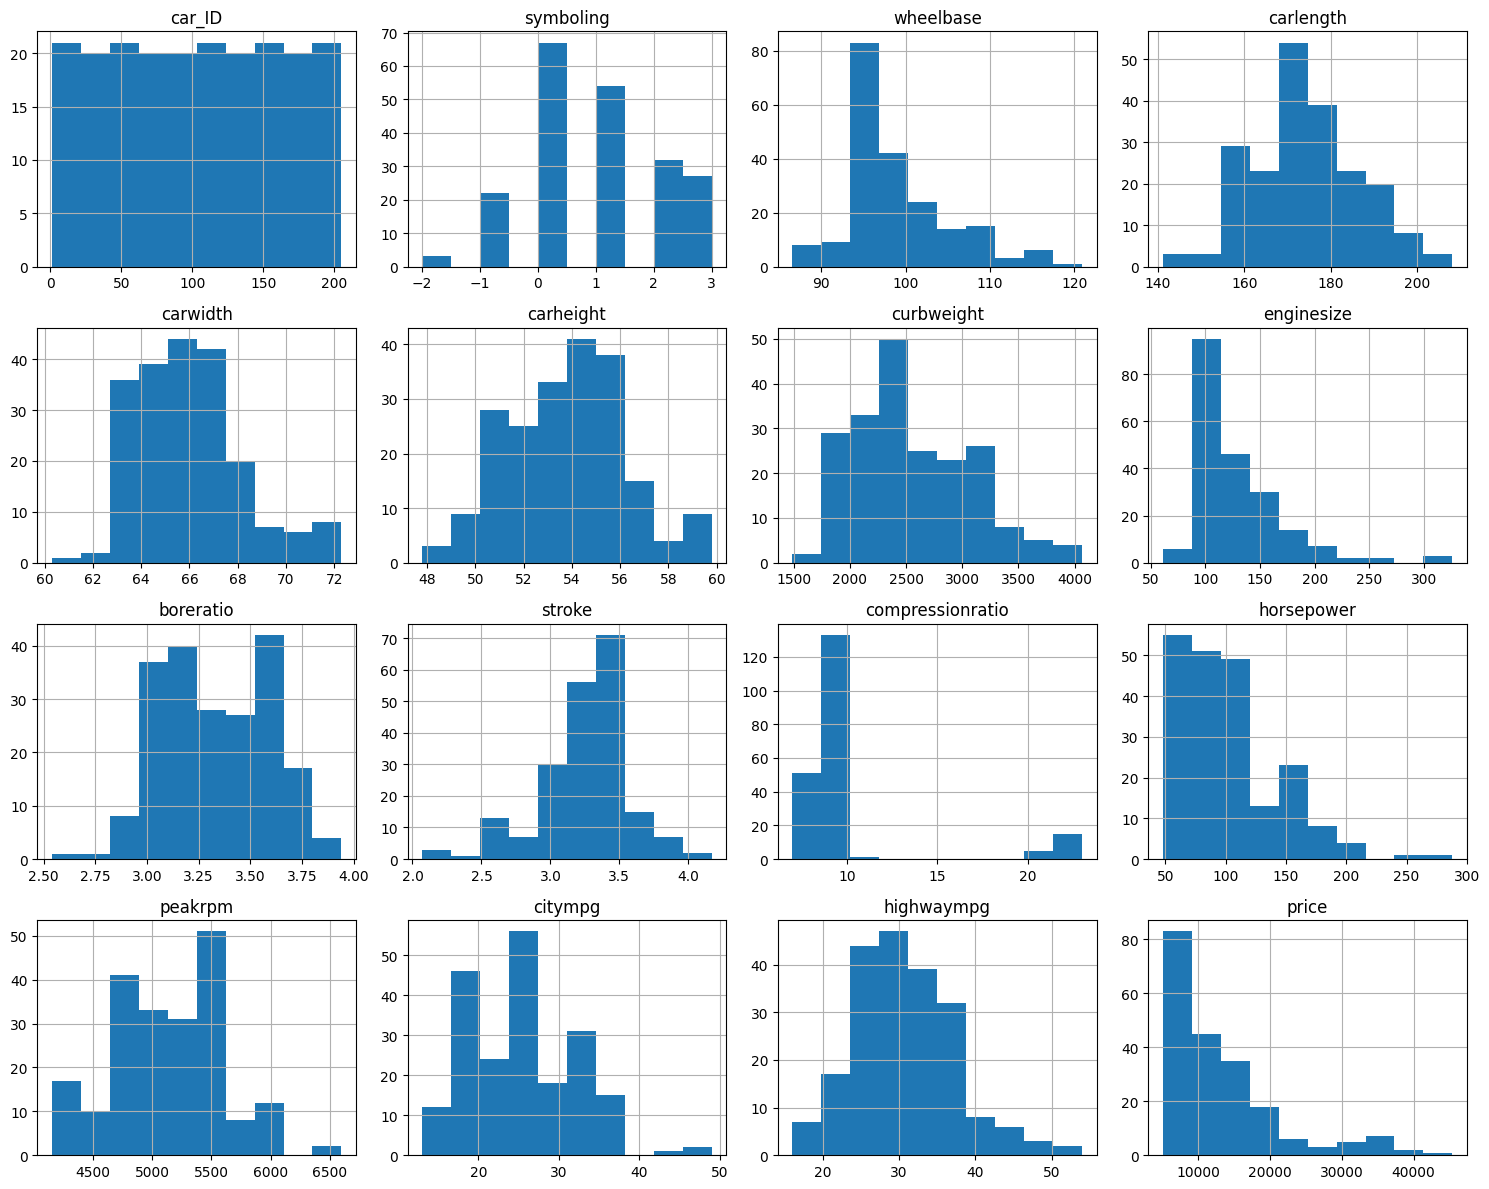

In [207]:
df[numerical_cols].hist(figsize=(15, 12))
plt.tight_layout()
plt.show()

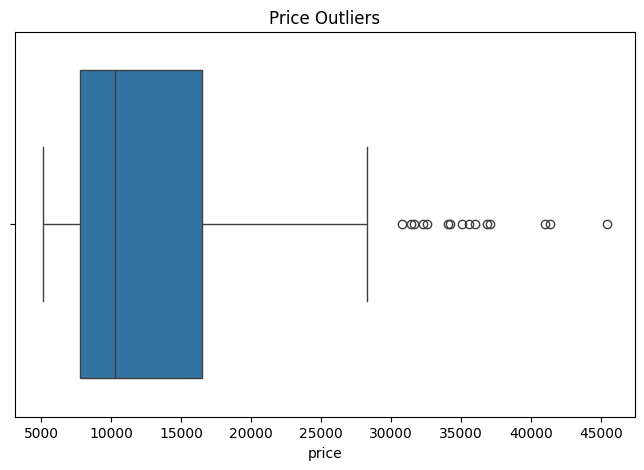

In [208]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df['price'])

plt.title("Price Outliers")

plt.show()

In [209]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['price'] < lower_bound) |
    (df['price'] > upper_bound)
]


**Visualization**

In [210]:
print(df['price'].describe())

count      205.000000
mean     13276.710571
std       7988.852332
min       5118.000000
25%       7788.000000
50%      10295.000000
75%      16503.000000
max      45400.000000
Name: price, dtype: float64


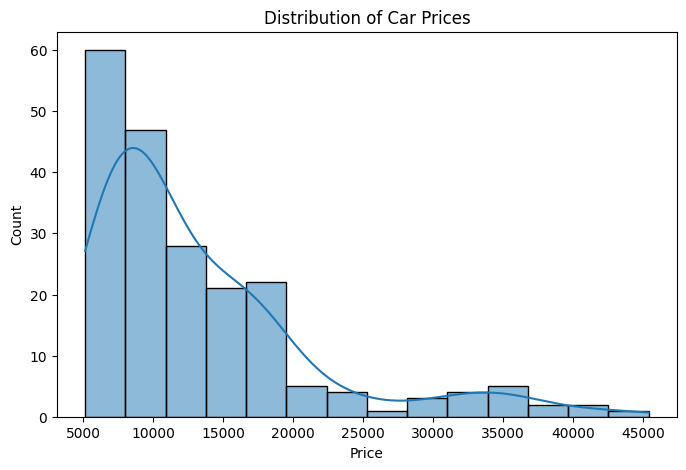

In [211]:
plt.figure(figsize=(8, 5))

sns.histplot(df['price'], kde=True)

plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.show()

In [212]:
correlation = df.corr(numeric_only=True)

price_corr = correlation['price'].sort_values(ascending=False)

print(price_corr)

price               1.000000
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
symboling          -0.079978
peakrpm            -0.085267
car_ID             -0.109093
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64


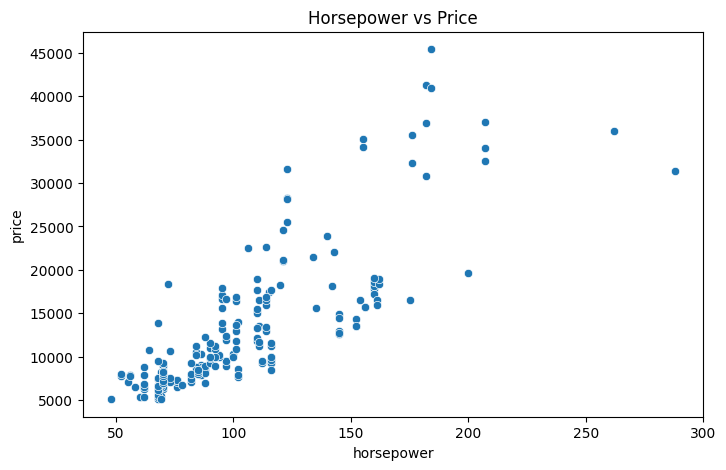

In [213]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='horsepower',
    y='price'
)

plt.title("Horsepower vs Price")
plt.show()

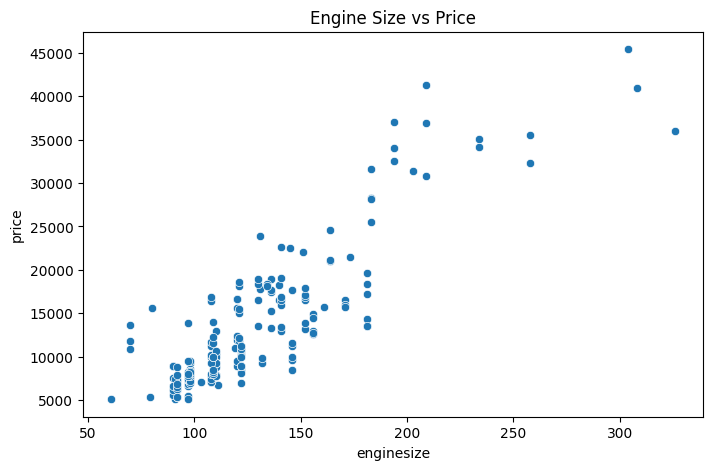

In [214]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='enginesize',
    y='price'
)

plt.title("Engine Size vs Price")
plt.show()

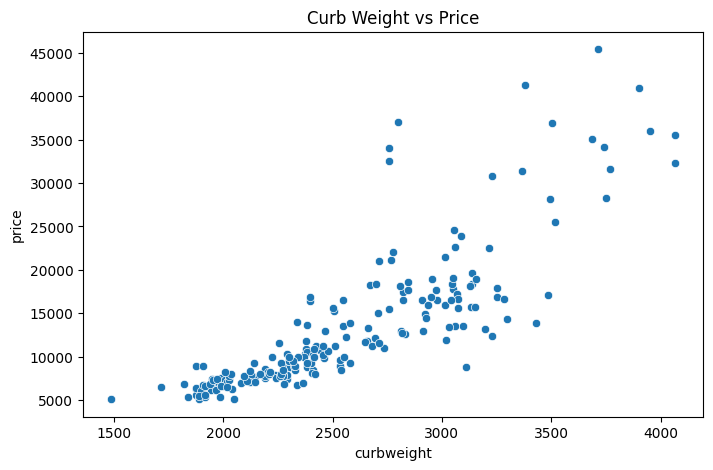

In [215]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='curbweight',
    y='price'
)

plt.title("Curb Weight vs Price")
plt.show()

**processing**

In [216]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(categorical_cols)


df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand']


In [217]:
X = df.drop('price', axis=1)
y = df['price']


In [218]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



In [219]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Modelling**

In [220]:
df.head(10)

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,...,brand_nissan,brand_peugeot,brand_plymouth,brand_porsche,brand_renault,brand_saab,brand_subaru,brand_toyota,brand_volkswagen,brand_volvo
0,1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,False,False,False,False,False,False,False,False,False,False
1,2,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,False,False,False,False,False,False,False,False,False,False
2,3,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,False,False,False,False,False,False,False,False,False,False
3,4,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,False,False,False,False,False,False,False,False,False,False
4,5,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,False,False,False,False,False,False,False,False,False,False
5,6,2,99.8,177.3,66.3,53.1,2507,136,3.19,3.40,...,False,False,False,False,False,False,False,False,False,False
6,7,1,105.8,192.7,71.4,55.7,2844,136,3.19,3.40,...,False,False,False,False,False,False,False,False,False,False
7,8,1,105.8,192.7,71.4,55.7,2954,136,3.19,3.40,...,False,False,False,False,False,False,False,False,False,False
8,9,1,105.8,192.7,71.4,55.9,3086,131,3.13,3.40,...,False,False,False,False,False,False,False,False,False,False
9,10,0,99.5,178.2,67.9,52.0,3053,131,3.13,3.40,...,False,False,False,False,False,False,False,False,False,False


In [221]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)



LinearRegression()

In [222]:
y_pred = model.predict(X_test_scaled)

In [223]:
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.2f}")

R² Score: 0.92


In [224]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1720.059985971761
RMSE: 2575.3689174937304


In [225]:
train_pred = model.predict(X_train_scaled)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Train R²:", train_r2)
print("Test R²:", test_r2)

Train R²: 0.975469353137747
Test R²: 0.9159844534483055


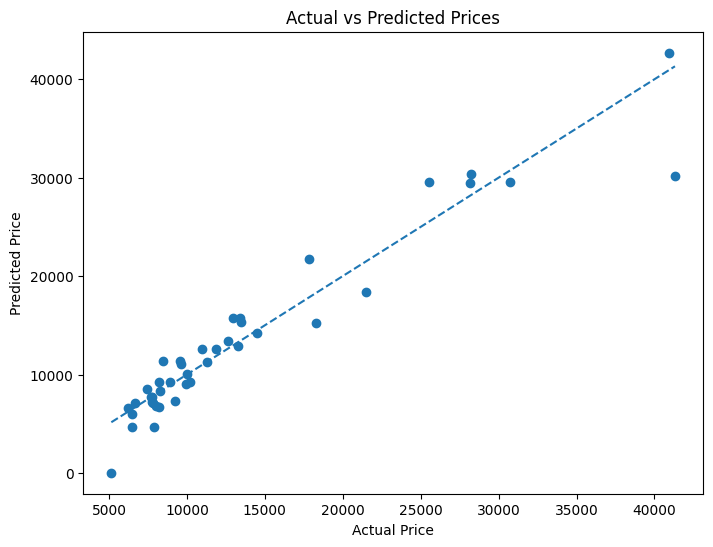

In [226]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()

**Insights**

1-Horsepower has a strong positive relationship with car price, with higher-powered cars generally having higher prices.

2-Curb Weight has a positive relationship with car price, as heavier cars generally tend to have higher prices.

3-Engine Size has the strongest positive relationship with car price. Larger engine sizes are generally associated with higher car prices.

4-Most cars are concentrated in the lower-to-mid price range, while high-priced cars represent a smaller portion of the dataset.

5-The Linear Regression model achieves a Test R² of 91.6%, indicating that the selected features capture most of the variation in car prices.

6-The predicted prices generally follow the actual car prices, indicating a strong overall relationship between predicted and actual prices.

In [227]:
import gradio as gr
import pandas as pd
import numpy as np

def predict_car_price(horsepower, enginesize, curbweight, highwaympg, fueltype, carbody):
    try:
        if 'X_train' in globals():
            input_df = X_train.mean().to_frame().T
        elif 'X' in globals():
            input_df = X.mean().to_frame().T
        else:
            feature_names = getattr(model, 'feature_names_in_', [])
            input_df = pd.DataFrame(0.0, index=[0], columns=feature_names)

        for col in input_df.columns:
            c_low = col.lower()
            if 'horsepower' in c_low:
                input_df.loc[0, col] = float(horsepower)
            elif 'enginesize' in c_low or 'engine_size' in c_low:
                input_df.loc[0, col] = float(enginesize)
            elif 'curbweight' in c_low or 'curb_weight' in c_low:
                input_df.loc[0, col] = float(curbweight)
            elif 'highwaympg' in c_low or 'highway_mpg' in c_low:
                input_df.loc[0, col] = float(highwaympg)

        for col in input_df.columns:
            c_low = col.lower()
            if 'fuel' in c_low:
                input_df.loc[0, col] = 1.0 if fueltype.lower() in c_low else 0.0
            if 'body' in c_low:
                input_df.loc[0, col] = 1.0 if carbody.lower() in c_low else 0.0

        if 'scaler' in globals() and scaler is not None:
            scaled_data = scaler.transform(input_df)
            predicted_price = model.predict(scaled_data)[0]
        else:
            predicted_price = model.predict(input_df)[0]

        return f"${predicted_price:,.2f}"

    except Exception as e:
        return f"Error: {str(e)}"


custom_css = """
body { direction: ltr; text-align: left; }
"""

with gr.Blocks(css=custom_css, title="Car Price Prediction App") as demo:
    gr.Markdown(
        """
        # 🚗 Car Price Prediction App
        ### Enter car specifications to get the estimated price
        """
    )

    with gr.Row():
        with gr.Column():
            gr.Markdown("### Technical Specifications")
            horsepower = gr.Number(label="Horsepower", value=110)
            enginesize = gr.Number(label="Engine Size", value=130)
            curbweight = gr.Number(label="Curb Weight", value=2500)
            highwaympg = gr.Number(label="Highway MPG", value=30)

            fueltype = gr.Dropdown(
                choices=["Gas", "Diesel"],
                label="Fuel Type",
                value="Gas"
            )
            carbody = gr.Dropdown(
                choices=["Sedan", "Hatchback", "Convertible", "Wagon"],
                label="Car Body",
                value="Sedan"
            )

            btn = gr.Button("✨ Estimate Price", variant="primary")

        with gr.Column():
            gr.Markdown("### Result")
            output = gr.Textbox(label="Estimated Price", placeholder="Estimated price will appear here...")

    btn.click(
        fn=predict_car_price,
        inputs=[horsepower, enginesize, curbweight, highwaympg, fueltype, carbody],
        outputs=output
    )

demo.launch(share=True)

/tmp/ipykernel_2440/1997003188.py:49: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css, title="Car Price Prediction App") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://58eb37bb02e5385c0d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [228]:
import joblib
from google.colab import files

model_data = {
    'model': model,
    'scaler': scaler,
    'columns': list(X.columns)
}

joblib.dump(model_data, 'model.pkl')
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>